#Multilayer neural network with hyperparameter optimisation

#####Universidad de Monterrey
#####Course: Artificial Intelligence II
#####Lecturer: Dr Andrés Hernández Gutiérrez

#Introduction
Multilayer neural networks, also known as multilayer perceptrons, extend the capabilities of
single-neural networks by introducing hidden layers composed of multiple neurons. These additional layers allow the model to learn complex non-linear relationships between input features
and the target variable.
Unlike single-neuron models, which can only learn linear decision boundaries, multilayer
neural networks can represent nonlinear decision surfaces, making them suitable for a range
of real-world applications. However, increasing model complexity introduces new challenges,
particularly the need to properly select the hyperparameters such as the number of layers,
number of neurons, learning rate, batch size, and regularisation technique.

#Team
- Camila González #599303
- Mariana Samperio #639835
- Matteo Peroni #689789




#Dataset
For this assignment we will be using the Dataset *IrisDataset* from [Kaggle.com](https://www.kaggle.com/datasets/souravbhattacharya10/irisdataset), which has the following numerical features:

- **petal_length**  
  Represents the length of the iris petal.

- **petal_width**  
  Represents the width of the iris petal.

- **sepal_length**  
  Represents the length of the iris sepal.

- **sepal_width**  
  Represents the width of the iris sepal.

  and our *target*
- **label**   
  Output. Refers to the Iris species.

This dataset contains a total of 50 rows, representing measurements of iris flowers and its objective is to classify flower species based on . The data is evenly distributed across three different species of Iris, with 50 samples per species.
Each row corresponds to a single iris flower sample. These measurements are commonly used for classification tasks and pattern recognition in machine learning, specifically useful in the *agriculture* world.

The objective of the Iris Dataset is to build a machine learning model that classifies iris flowers into their correct species based on their physical measurements.

First we will be importing the key libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Data Cleaning

On this next lines of code we will be importing our database.

In [3]:
df = pd.read_csv('Iris.csv')
df.head()


,petal_length,petal_width,sepal_length,sepal_width,label
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


These next few blocks will help us get aquainted with our database .  
First we will check the statistical summary of the dataset

In [4]:
df.describe()

,petal_length,petal_width,sepal_length,sepal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


As we can see from the summary, all the features are numeric (float), therefore they are quantitative variables.

**Sepal length**: has a mean of 5.84 cm and a standard deviation of 0.83 cm. This means that, on average, the values tend to vary about 0.83 cm above or below the mean. The values range from 4.3 cm to 7.9 cm.

**Sepal width**: has a mean of 3.05 cm and a standard deviation of 0.43 cm, meaning that the values typically deviate about 0.43 cm from the mean. The range goes from 2.0 cm to 4.4 cm.

**Petal length**: has a mean of 3.76 cm and a standard deviation of 1.76 cm, indicating that the values vary considerably around the mean. The range is from 1.0 cm to 6.9 cm.

**Petal width**: has a mean of 1.20 cm and a standard deviation of 0.76 cm, meaning that values typically differ by about 0.76 cm from the mean. The values range from 0.1 cm to 2.5 cm.

Petal length and petal width show higher variability compared to sepal measurements, suggesting that petal features may provide stronger discriminatory power for classifying the iris species.

Next, we want to examine the data types of each column

In [5]:
df.dtypes

,0
petal_length,float64
petal_width,float64
sepal_length,float64
sepal_width,float64
label,object


This next block will help us determine whether our database is balanced

In [6]:
df['label'].value_counts()

,count
label,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


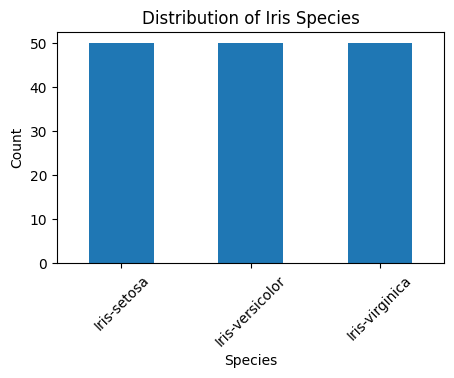

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))
df['label'].value_counts().plot(kind='bar')
plt.title('Distribution of Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

as we can see, all three classes have the same number of samples, meaning the dataset is balanced.

Next step is to check for any missing values on our dataset.

In [9]:
df.isnull().sum()

,0
petal_length,0
petal_width,0
sepal_length,0
sepal_width,0
label,0


luckily, there are no missing values.

#EDA

Now we will visualize the distribution of each feature in the dataset, iterating through all columns in the DataFrame except the last one (our target)

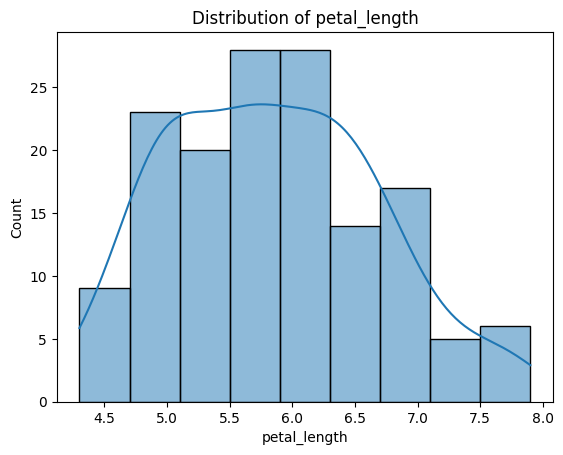

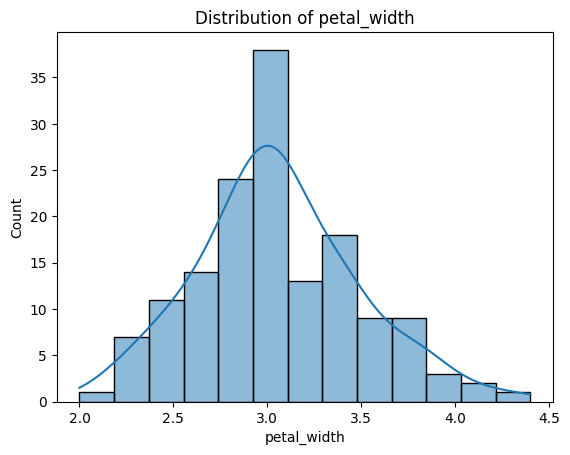

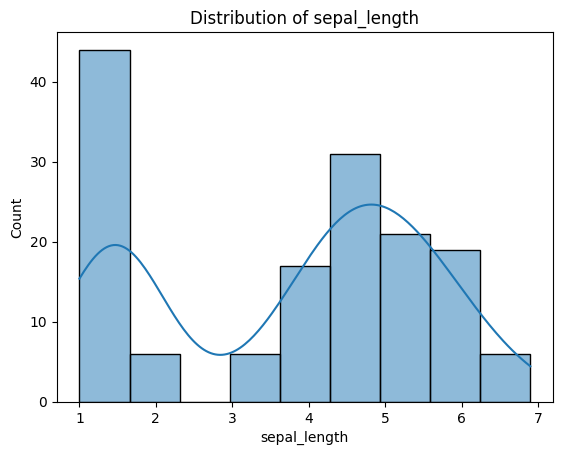

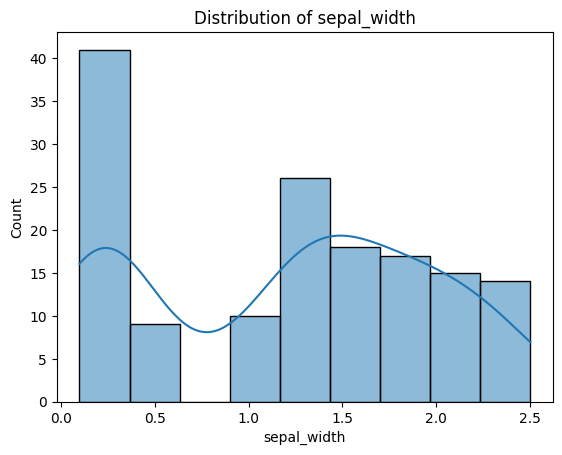

In [ ]:
for col in df.columns[:-1]:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

From the distributions, sepal length and petal length exhibit wider ranges and greater variability across the observations. Sepal width appears more concentrated around its central values, indicating lower dispersion. In contrast, petal width shows clearer clustering patterns, suggesting a stronger separation between the species and making it a particularly informative feature for classification.

These boxplots will help compare the four Iris features across the three species: setosa, versicolor, and virginica.

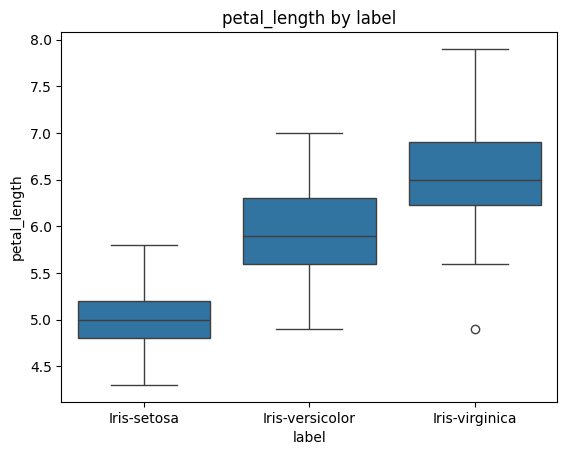

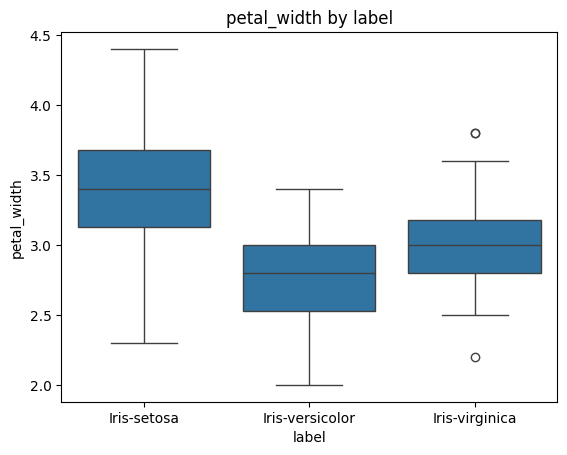

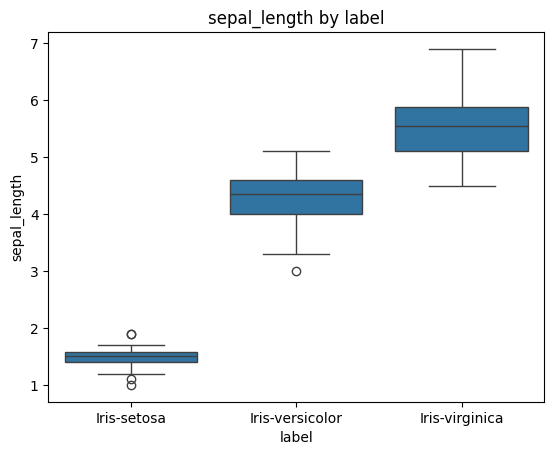

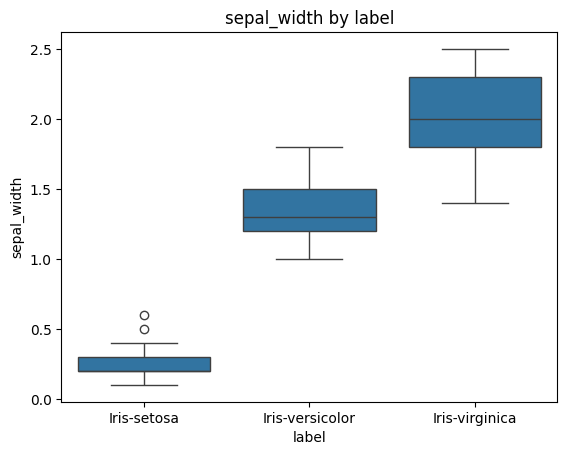

In [10]:
for col in df.columns[:-1]:
    plt.figure()
    sns.boxplot(x='label', y=col, data=df)
    plt.title(f'{col} by label')
    plt.show()

Results show clear differences between species. Petal length and petal width increase progressively from setosa to versicolor to virginica, making these features strong indicators for distinguishing the species.

These following lines will give us the correlation matrix, so we can analyze the relationship between the numerical variables in the dataset.


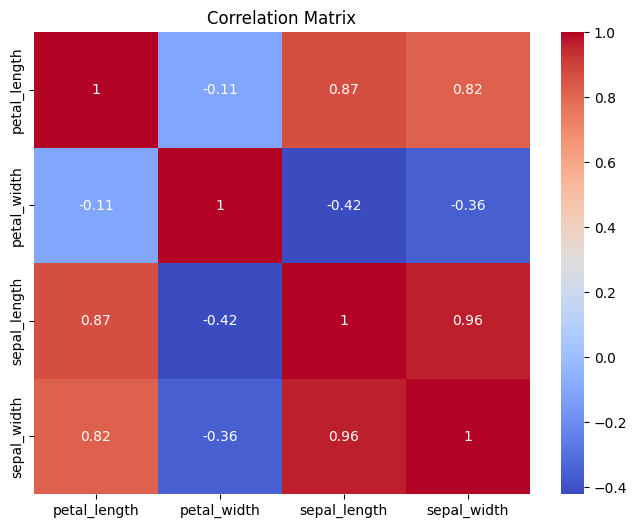

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

The matrix shows that some features have strong positive correlations, such as sepal_length and sepal_width (0.96).

We kept all features because, despite some correlations, each one still provides useful information. Since the dataset is small, removing features could lead to loss of important data, and the correlations are not problematic enough to justify dropping any variables.

Next, we are going to explore relationships between all pairs of features in the dataset. This is done using a pairplot, which generates a grid of scatter plots comparing every combination of variables

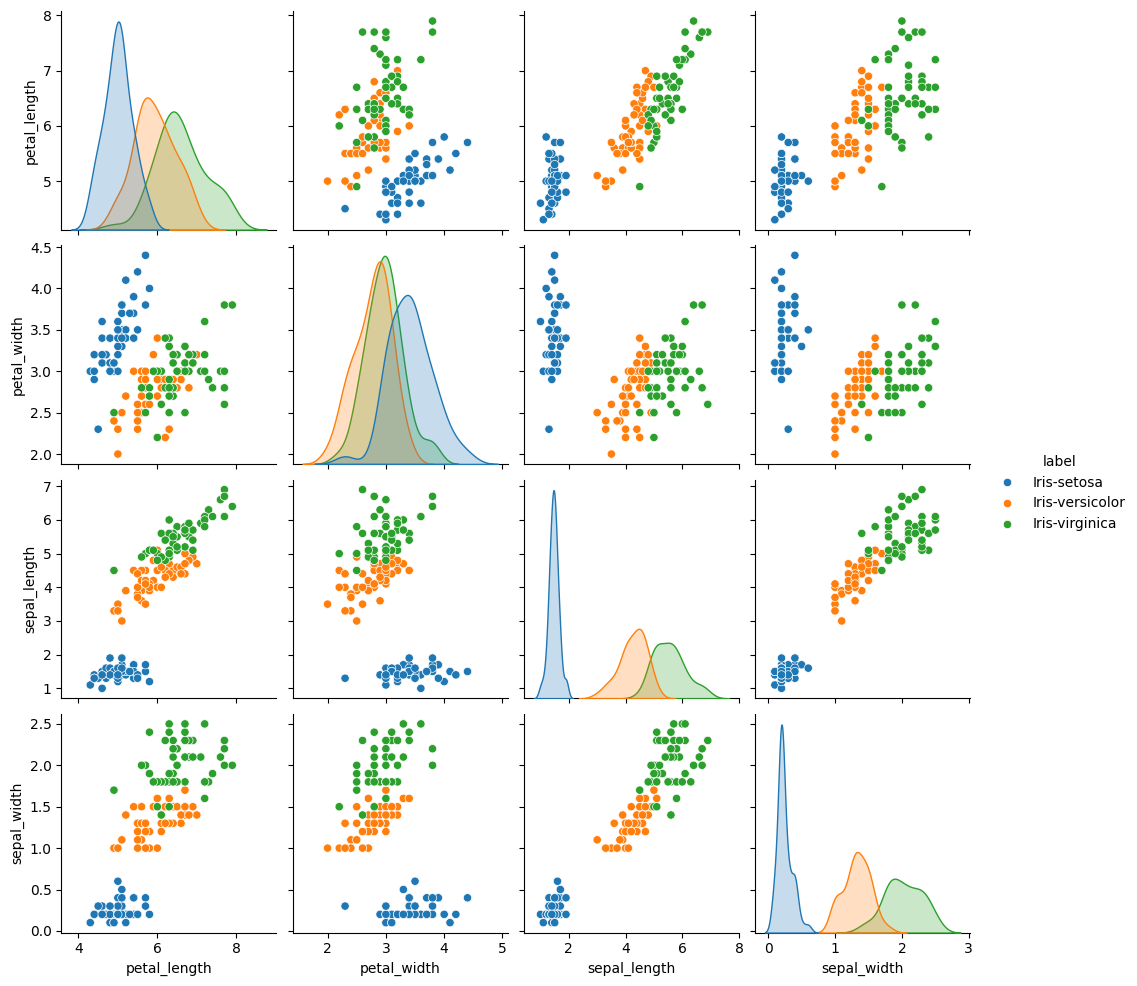

In [ ]:
# Pairplot
sns.pairplot(df, hue='label')
plt.show()

we can see how petal length and petal width provide the clearest separation between species, with Iris-setosa forming a completely distinct cluster and almost no overlap with the others. Versicolor and virginica show some overlap but still follow a clear increasing trend, especially in petal measurements.

#Design & Training Model

In this next step, the dataset will be prepared for modeling by separating the features and the labels. The features will be standardized to ensure that all variables are on the same scale, which can improve the performance of many machine learning models. The labels will also be encoded into numerical values so that they can be used by machine learning algorithms.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

labels = df['label'].values
features = df.drop('label', axis=1)

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

features = features_scaled

# Encode string labels to numerical labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

labels = labels_encoded

features.shape

(150, 4)

Now it's time to split the dataset into training and testing sets. A portion of the data (80%) will be used to train the model, while the remaining 20% is reserved for evaluating its performance.

In [ ]:
SEED = 42

x_train, x_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

y_train.shape

(120,)

#Hyperparameters Optimisation

In this step, the Optuna library is installed to enable hyperparameter optimisation. This tool is used to efficiently search for the best combination of model parameters, such as learning rate, batch size, and network architecture, as required in the assignment.

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.3 MB/s eta 0:00:00


Now the required libraries are imported to support model development and hyperparameter optimisation.

In [ ]:
import optuna
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [ ]:
from __future__ import annotations
from typing import Callable, Tuple
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping

This function allows the user to choose the hyperparameter optimisation method, either grid search or Bayesian optimisation.

In [ ]:
def choose_optimisation():
  choice = input("Select optimisation method (GS,BO): ")
  return choice.lower()

This function defines the objective to be optimised during hyperparameter tuning. It builds and trains a neural network using parameters suggested by Optuna and returns the model’s accuracy on the validation set.

In [ ]:
def build_objective(method,data):

  x_train, x_test, y_train, y_test = data
  input_dim = x_train.shape[1]

  def objective(trial):
    tf.keras.backend.clear_session()
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    epochs = trial.suggest_int("epochs", 10, 150)
    batch_size = trial.suggest_categorical("batch_size", [32,64,16])
    layers = trial.suggest_int("n_layers", 2, 4)
    neurons = trial.suggest_int("n_neurons", 16, 512, log=True)

    model = tf.keras.Sequential()

    model.add(tf.keras.layers.Dense(neurons, input_dim=input_dim, activation='relu'))

    for i in range(layers - 1):
      model.add(tf.keras.layers.Dense(neurons, activation='relu'))

    model.add(tf.keras.layers.Dense(3, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    history = model.fit(
        x_train,y_train,
        validation_data=(x_test,y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=EarlyStopping(patience=5, monitor="val_loss", restore_best_weights=True),
        verbose=0
    )

    _, accuracy = model.evaluate(x_test,y_test)
    return float(accuracy)

  return objective

The hyperparameter optimisation process begins! If Bayesian optimisation is selected, it uses a TPE sampler to efficiently explore the search space over a fixed number of trials but if grid search is chosen, it defines a set of  values for each hyperparameter and evaluates all possible combinations.
We will be working this time with *Bayesian optimization*.

In [ ]:
def create_study(objective,method):
  if method == "bo":
    print("Running Bayesian Optimization")

    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction="maximize", sampler=sampler)

    study.optimize(objective, n_trials=10)

    return study

  elif method == "gs":
    print("Running Grid Search")

    lr_grid = list(np.logspace(np.log10(1e-5),np.log10(1e-1),num=3))
    epochs_grid = [50,100,150]
    batch_grid = [16,32,64]
    layers_grid = [1,2,3]
    n_neurons_grid = [16,32,64]

    search_space = {
        "lr": lr_grid,
        "epochs": epochs_grid,
        "batch_size": batch_grid,
        "n_layers": layers_grid,
        "n_neurons": n_neurons_grid
    }

    print("\n\tlr_grid:", lr_grid)
    print("\tepochs_grid:", epochs_grid)
    print("\tbatch_grid:", batch_grid)
    print("\tlayers_grid:", layers_grid)
    print("\tn_neurons_grid:", n_neurons_grid)
    print("\tunique epochs:", sorted(set(epochs_grid)))

    grid_size = len(lr_grid) * len(set(epochs_grid)) * len(batch_grid) * len(layers_grid) * len(n_neurons_grid)
    print("\n\tgrid size:", grid_size)

    sampler = optuna.samplers.GridSampler(search_space)
    study = optuna.create_study(direction="maximize", sampler=sampler)

    study.optimize(objective)

    return study

Visualisations of the hyperparameter optimisation results are generated in this function. It displays parameter importance to show which hyperparameters have the greatest impact on model performance.

In [ ]:
def show_optuna_visualisations(study: optuna.Study) -> None:
    optuna.visualization.plot_param_importances(study).show()
    optuna.visualization.plot_parallel_coordinate(study).show()

#Study Launch

In this next section, the optimisation process is run. The method is chosen, the model is tested with different hyperparameter values, and the best results are identified. Finally, visualisations are created to help understand how the parameters affected performance.

In [ ]:
#Study launch
method = choose_optimisation()
objective = build_objective(method,(x_train, x_test, y_train, y_test))
study = create_study(objective,method)

Select optimisation method (GS,BO): bo


[I 2026-04-06 00:11:06,640] A new study created in memory with name: no-name-dc63f784-12d2-4d6f-aaf7-a597de9042da


Running Bayesian Optimization
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9667 - loss: 0.1866


[I 2026-04-06 00:11:33,764] Trial 0 finished with value: 0.9666666388511658 and parameters: {'lr': 0.00031489116479568613, 'epochs': 144, 'batch_size': 32, 'n_layers': 2, 'n_neurons': 19}. Best is trial 0 with value: 0.9666666388511658.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.0218


...

[I 2026-04-06 00:12:29,886] Trial 7 finished with value: 0.9333333373069763 and parameters: {'lr': 5.4880470007660426e-05, 'epochs': 146, 'batch_size': 64, 'n_layers': 3, 'n_neurons': 390}. Best is trial 1 with value: 1.0.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9000 - loss: 0.5875


[I 2026-04-06 00:12:36,405] Trial 8 finished with value: 0.8999999761581421 and parameters: {'lr': 2.259279742015695e-05, 'epochs': 37, 'batch_size': 16, 'n_layers': 2, 'n_neurons': 282}. Best is trial 1 with value: 1.0.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0298


[I 2026-04-06 00:12:44,181] Trial 9 finished with value: 1.0 and parameters: {'lr': 0.00026730883107816685, 'epochs': 49, 'batch_size': 16, 'n_layers': 2, 'n_neurons': 490}. Best is trial 1 with value: 1.0.


In [ ]:
#Visualize the performance
show_optuna_visualisations(study)

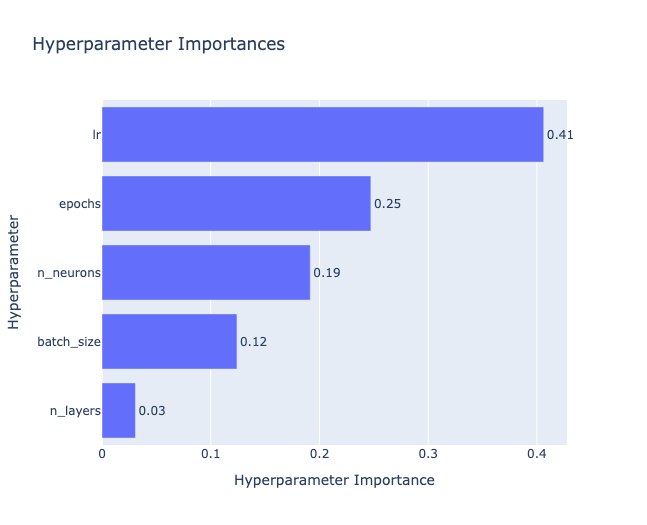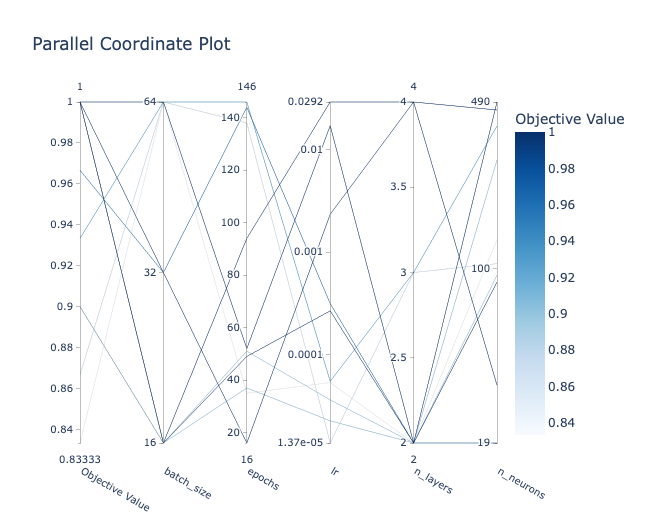

the plot plot shows that the learning rate has the biggest impact on model performance, followed by the number of epochs and the number of neurons. This means that how fast the model learns, how long it trains, and the size of the network are the most important factors in achieving good results.

This is important because it helps focus optimisation on the parameters that actually matter, saving time and computational resources while improving the model more effectively.

#Best Model

Here, the final neural network model is built using the best hyperparameters found during optimisation. The model is then trained on the training data and validated on the test data. Early stopping is applied to prevent overfitting by stopping training when performance stops improving.

In [ ]:
study.best_params

{'lr': 0.029154431891537533,
 'epochs': 94,
 'batch_size': 16,
 'n_layers': 4,
 'n_neurons': 33}

The best parameters found during the optimization process are shown above. In the next cell, the model will be trained using the best hyperparameters obtained from the study conducted with Optuna:

- **Learning rate (lr)**: 0.02915
- **Epochs**: 94
- **Batch size**: 16
- **Number of layers**: 4
- **Number of neurons per layer**: 33

In [ ]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.backend.clear_session()

best_model = tf.keras.Sequential([
    tf.keras.layers.Dense(33, activation='relu', input_shape=(x_train.shape[1],)),
    tf.keras.layers.Dense(33, activation='relu'),
    tf.keras.layers.Dense(33, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=study.best_params["lr"]),
    loss=SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

history = best_model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=study.best_params["epochs"],
    batch_size=study.best_params["batch_size"],
    callbacks=EarlyStopping(patience=5, monitor="val_loss", restore_best_weights=True),
    verbose=1
)

Epoch 1/94
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7250 - loss: 0.5509 - val_accuracy: 0.9667 - val_loss: 0.2524
Epoch 2/94
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8583 - loss: 0.3385 - val_accuracy: 0.9667 - val_loss: 0.1223
Epoch 3/94
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9500 - loss: 0.1457 - val_accuracy: 0.9333 - val_loss: 0.1903
Epoch 4/94
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9167 - loss: 0.3421 - val_accuracy: 1.0000 - val_loss: 0.0119
Epoch 5/94
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9583 - loss: 0.1017 - val_accuracy: 0.9667 - val_loss: 0.0503
Epoch 6/94
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9750 - loss: 0.0753 - val_accuracy: 1.0000 - val_loss: 0.0316
Epoch 7/94
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9750 - loss: 0.0661 - val_accuracy: 1.0000 - val_loss: 0.0129
Epoch 8/94
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9583 - loss: 0.0706 - val_accuracy: 0.9667 - val_loss: 0.1089


**Number of Optimisation Trials**   
A total of 10 optimisation trials were performed for the hyperparameter search using Optuna.

This relatively small number of trials was intentionally selected to ensure fast execution in Google Colab, since increasing the number of trials would significantly increase the computational time.

Given that the Iris Dataset is small, well-structured, and highly separable, an extensive hyperparameter search is not necessary to achieve good performance. For this reason, Bayesian optimisation was used to efficiently explore the hyperparameter space.

Additionally, early stopping was applied during training. The procedure monitored the validation loss, and training was stopped if no improvement was observed for 5 consecutive epochs (patience = 5).

Therefore, 10 trials represent a reasonable balance between computational efficiency and exploration of the hyperparameter space.


**Best Hyperparameter Configuration**       

The best configuration corresponds to the trial with the highest validation accuracy among the 10 trials.

Best configuration:
- **Learning rate (lr)**: 0.02915
- **Epochs**: 94
- **Batch size**: 16
- **Number of layers**: 4
- **Number of neurons per layer**: 33

Using Bayesian optimisation, each trial is guided by previous results, allowing the search to focus on promising regions of the hyperparameter space.

Although only 10 trials were performed, this configuration represents the best solution found within the explored space and achieved near-perfect performance, which is sufficient for this dataset.



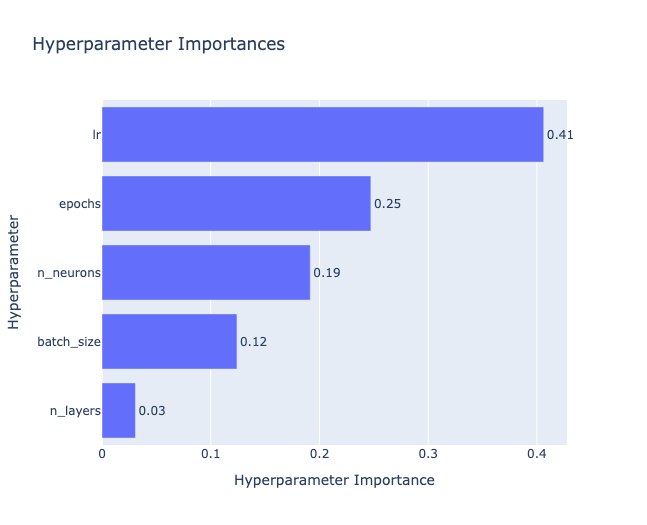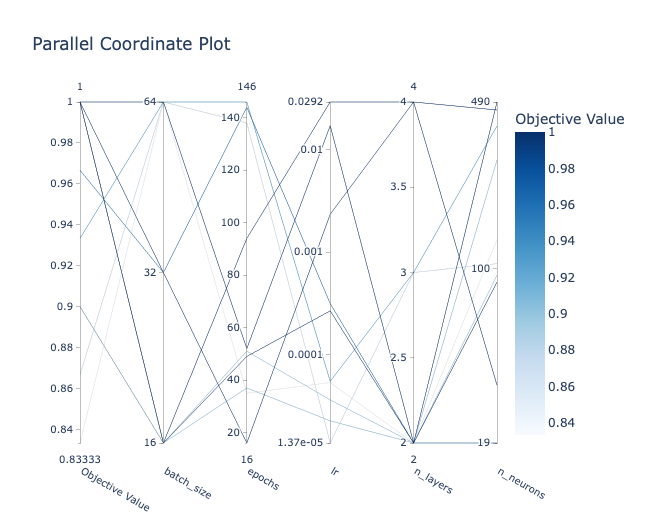

**Hyperparameter Importance and Parallel Coordinate Analysis**

The importance plot shows that the learning rate (0.41) is the most influential hyperparameter, indicating that it has the greatest impact on model performance. The number of epochs (0.25) also plays a relevant role in determining the final performance of the model.

The number of neurons (0.19) has a moderate influence, while batch size (0.12) has a smaller effect. Finally, the number of layers (0.03) appears to have minimal impact on the model’s performance.

The parallel coordinate plot shows that high accuracy can be achieved across multiple hyperparameter combinations. This suggests that the dataset is relatively easy to classify and does not require a very specific configuration of hyperparameters.

Overall, the results indicate that tuning the learning rate and the number of epochs is more important than adjusting the model depth or the batch size when optimizing the model.

#Learning Curves

This step visualises the model’s performance throughout training by plotting accuracy and loss across epochs for both training and validation sets.

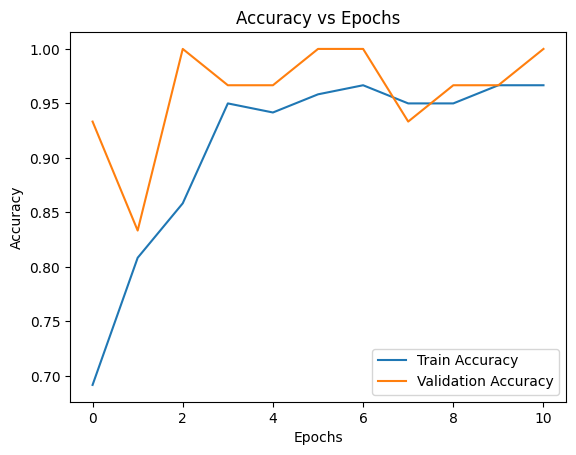

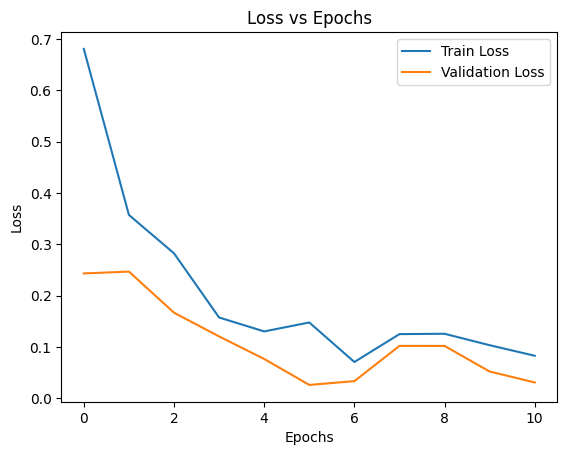

In [ ]:
history_dict = history.history

# Accuracy
plt.plot(history_dict['accuracy'], label='Train Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')
plt.show()

# Loss
plt.plot(history_dict['loss'], label='Train Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs')
plt.show()

It is noticeable that both the training loss and the validation loss decrease over time and remain close to each other. This indicates that the model is learning effectively and performing similarly on both datasets.

Overall, the model shows appropriate fitting, as there are no clear signs of overfitting or underfitting.

#Evaluation

Now it's time to test the model on unseen data to assess its overall performance.

In [ ]:
_, accuracy = best_model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.0262
Test Accuracy: 1.0


The model achieves a test accuracy of 1.0, indicating perfect classification on the test dataset. This suggests that the model performs extremely well.

The following lines of code will help evaluate the model’s classification performance in more detail with a confusion matrix.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


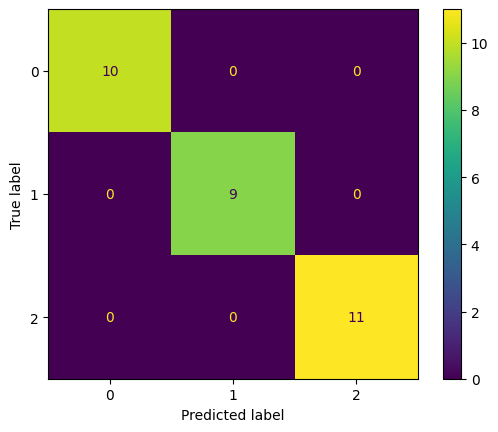

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_model.predict(x_test).argmax(axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

The confusion matrix shows that all predictions fall along the diagonal, meaning every class was classified correctly.

These next lines of code will help evaluate the performance of our model computing the overall accuracy and generating a classification report to analyze precision, recall, and F1-score for each class.
We will also assess the model on test datasets to compare their accuracies and better understand how well the model generalizes to unseen data.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 1.0

Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [ ]:
train_acc = best_model.evaluate(x_train, y_train, verbose=0)[1]
test_acc = best_model.evaluate(x_test, y_test, verbose=0)[1]

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9666666388511658
Test Accuracy: 1.0


The results indicate that the model achieves perfect performance on the test set, with all evaluation metrics equal to 1.0 across the three classes.

#Save and load the model

Lastly we will be saving our model

In [ ]:
best_model.save('best_model.h5')

from tensorflow.keras.models import load_model
best_model = load_model('best_model.h5')

Model saving is important in practice because it allows trained machine learning models to be reused without needing to retrain them every time as it can be time-consuming and computationally expensive.

#Personal conclusions

**Camila**:     
This assignment demonstrated that multilayer neural networks can achieve excellent performance on structured and well-separated datasets such as Iris, especially when proper preprocessing and feature scaling are applied. A key insight was that certain hyperparameters, particularly the learning rate and number of epochs, have a significant impact on model performance, while others like batch size and number of layers play a less critical role in simpler problems. One of the main challenges encountered was managing computational time during hyperparameter optimisation, which highlighted the importance of using efficient methods such as Bayesian Optimisation (Optuna) instead of exhaustive approaches. This optimisation strategy proved effective in identifying high-performing configurations with a limited number of trials. Additionally, early stopping was essential in preventing overfitting and reducing unnecessary training, allowing the model to generalise well without excessive computation. This assignment reinforced the importance of systematic experimentation, proper tuning, and validation when training neural networks.

[GitHub Repository](https://github.com/camilagzzaa/Multilayer_neural_network_with_hyperparameter_optimisation.git)

**Mariana**:

This assignment made it clear that the structure of a neural network plays a major role in its performance. Choosing the number of layers and neurons is not just a design choice, but something that directly affects how well the model can learn patterns from the data. I noticed that adding more complexity does not always improve results, especially for simpler datasets, and that a well-balanced architecture often performs better than an unnecessarily large one.

A key part of this work was hyperparameter optimisation, which helped explore different configurations in a more efficient way. Instead of guessing values, the optimisation process allowed the model to test combinations of learning rate, batch size, and architecture, and gradually find better solutions. This showed me how sensitive neural networks are to these parameters and how important it is to search for good settings.
Early stopping also complemented this process by preventing the model from training longer than needed, which helped maintain good performance while reducing training time.
[GitHub Repository](https://github.com/mariana-samperio-cuevas/multilayer_nn_hyperparameter_optimisation)

**Matteo**: This project provided a better understanding of training multi-layer models for multi-label classification. A key takeaway is how optimization algorithms help progressively find better solutions: even if a global minimum is not guaranteed, iterating on promising hyperparameter configurations allows us to improve performance and explore more effective regions of the search space. Although we reached the maximum accuracy score.

Some challenges included defining a suitable objective function for Optuna and designing models with varying numbers of layers. Despite this, hyperparameter optimization proved to be very effective, especially on more complex datasets. Optuna made the process easier and its visualization tools, such as hyperparameter importance plots, were particularly useful.

Early stopping also played an important role by reducing training time and limiting overfitting during optimization. However, it can sometimes make results harder to interpret, for example, when the importance of the number of epochs is overestimated because training often stops earlier than the maximum allowed.

In our case Bayesian Optimisation works better because faster and we reached the same accuracy of 100%.

[GitHub Repository](https://github.com/perofficial/mlp_hyperparameters_optimisation)

*We hereby declare we have done this activity with academic integrity*